# Importing Libraries and Loading Dataset

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
df1 = pd.read_excel("Bottle data/Bottle Oxygen Data.xlsx", engine="openpyxl")
df2 = pd.read_csv("Glider data/scotia_20210719_136_delayed_corrected_v4.csv", encoding="latin1")


# Display basic info about datasets
print("Dataset 1 Info:")
df1.info()
print("\nDataset 2 Info:")
df2.info()

df1.head(), df2.head()

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Station_ID        863 non-null    object 
 1   Year_UTC          863 non-null    int64  
 2   Month_UTC         863 non-null    int64  
 3   Day_UTC           863 non-null    int64  
 4   Hour_UTC          863 non-null    int64  
 5   Minute_UTC        863 non-null    int64  
 6   Latitude          863 non-null    float64
 7   Longitude         863 non-null    float64
 8   Cast_number       863 non-null    object 
 9   Sample_ID         863 non-null    object 
 10  CTDPRES           863 non-null    float64
 11  CTDPRES_FLAG      863 non-null    int64  
 12  CTDTEMP           863 non-null    float64
 13  CTDTEMP_FLAG      863 non-null    int64  
 14  CTDSAL            863 non-null    float64
 15  CTDSAL_FLAG       863 non-null    int64  
 16  CTDOXY            863 non-nu

(  Station_ID  Year_UTC  Month_UTC  Day_UTC  Hour_UTC  Minute_UTC   Latitude  \
 0          1      2021         10       22        21           7  49.101389   
 1          1      2021         10       22        21           7  49.101389   
 2          1      2021         10       22        21           7  49.101389   
 3          1      2021         10       22        21           7  49.101389   
 4          1      2021         10       22        21           7  49.101389   
 
    Longitude Cast_number Sample_ID  ...  CTDTEMP  CTDTEMP_FLAG   CTDSAL  \
 0   -67.2775     TRXD001  D-001132  ...   6.2055             2  34.5830   
 1   -67.2775     TRXD001  D-001133  ...   5.4780             2  34.2430   
 2   -67.2775     TRXD001  D-001134  ...   4.4462             2  33.7871   
 3   -67.2775     TRXD001  D-001135  ...   1.6449             2  32.3563   
 4   -67.2775     TRXD001  D-001136  ...  10.2512             2  30.3845   
 
    CTDSAL_FLAG      CTDOXY  CTDOXY_FLAG      Oxygen  Oxygen

---

#  Data Cleaning

Next,
- Replacing -999.000000 values with NaN.
- Dropping rows with missing key values.
- Checking for remaining missing values.
- Converting the timestamp columns to a proper datetime format in both datasets.
- Merging the datasets using a nearest-time approach.
- Using Z-score filtering with a threshold of 3 to remove extreme outliers.

In [3]:
# replacing -999.000000 with NaN in oxygen columns
df1.replace(-999.000000, np.nan, inplace=True)
df2.replace(-999.000000, np.nan, inplace=True)

# dropping rows with missing key values
df1.dropna(subset=["best_Oxygen", "Latitude", "Longitude", "CTDTEMP", "CTDSAL"], inplace=True)
df2.dropna(subset=["micromoles_of_oxygen_per_unit_mass_in_sea_water", "latitude", "longitude", "sea_water_temperature", "sea_water_practical_salinity"], inplace=True)


print(df1.isnull().sum()) 
print(df2.isnull().sum())


Station_ID            0
Year_UTC              0
Month_UTC             0
Day_UTC               0
Hour_UTC              0
Minute_UTC            0
Latitude              0
Longitude             0
Cast_number         359
Sample_ID           359
CTDPRES               0
CTDPRES_FLAG          0
CTDTEMP               0
CTDTEMP_FLAG          0
CTDSAL                0
CTDSAL_FLAG           0
CTDOXY                0
CTDOXY_FLAG           0
Oxygen              458
Oxygen_FLAG           0
best_Oxygen           0
best_Oxygen_FLAG      0
dtype: int64
time                                               0
latitude                                           0
longitude                                          0
depth                                              0
sea_water_temperature                              0
sea_water_practical_salinity                       0
sea_water_density                                  0
micromoles_of_oxygen_per_unit_mass_in_sea_water    0
dtype: int64


In [4]:
# checking datatypes, nulls, and preview of specific columns
cols = ["Year_UTC", "Month_UTC", "Day_UTC", "Hour_UTC", "Minute_UTC"]
print(df1[cols].dtypes)
print(df1[cols].isnull().sum())
print(df1[cols].head(10))

Year_UTC      int64
Month_UTC     int64
Day_UTC       int64
Hour_UTC      int64
Minute_UTC    int64
dtype: object
Year_UTC      0
Month_UTC     0
Day_UTC       0
Hour_UTC      0
Minute_UTC    0
dtype: int64
   Year_UTC  Month_UTC  Day_UTC  Hour_UTC  Minute_UTC
0      2021         10       22        21           7
1      2021         10       22        21           7
2      2021         10       22        21           7
3      2021         10       22        21           7
4      2021         10       22        21           7
5      2021         10       22        21           7
6      2021         10       23         2          10
7      2021         10       23         2          10
8      2021         10       23         2          10
9      2021         10       23         6          53


In [5]:
# converting the columns in df1 to datetime format
df1["time"] = pd.to_datetime(
    df1[["Year_UTC", "Month_UTC", "Day_UTC", "Hour_UTC", "Minute_UTC"]].rename(
        columns={"Year_UTC": "year", "Month_UTC": "month", "Day_UTC": "day", "Hour_UTC": "hour", "Minute_UTC": "minute"}
    )
)

df2["time"] = pd.to_datetime(df2["time"], errors="coerce")

#merging the 2 datasets
merged_df = pd.merge_asof(df1.sort_values("time"), df2.sort_values("time"), on="time", direction="nearest")

In [6]:
#removing outliers using zscore
z_scores = np.abs(stats.zscore(merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]]))
merged_df = merged_df[(z_scores < 3).all(axis=1)]

In [7]:
#Hypothesis Testing
#testing the correlation significance between oxygen and temperature
corr, p_value = stats.pearsonr(merged_df["best_Oxygen"], merged_df["CTDTEMP"])
print(f"Correlation between Oxygen and Temperature: {corr:.2f} (p-value: {p_value:.5f})")

Correlation between Oxygen and Temperature: -0.38 (p-value: 0.00000)


- The negative correlation makes sense, because when temperatures go up, the amount of oxygen in water usually goes down, since warm water can't hold as much oxygen.

---

# Visualizations And Explorations


- Visualize relationship between oxygen concentration and temperature using scatter plots and regression lines.
- Explore other relationships between oxygen concentration and other factors like salinity, depth etc.
- Build prediction models using the cleaned and merged dataset.
- Interpret the results.

## Oxygen vs. Temperature & Salinity


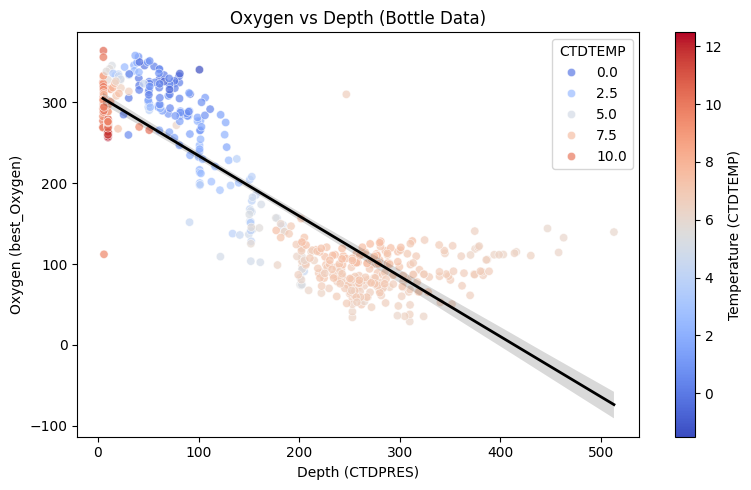

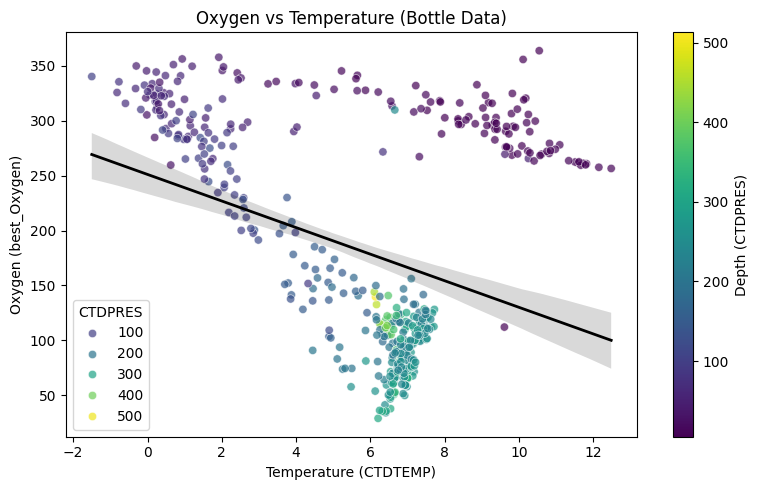

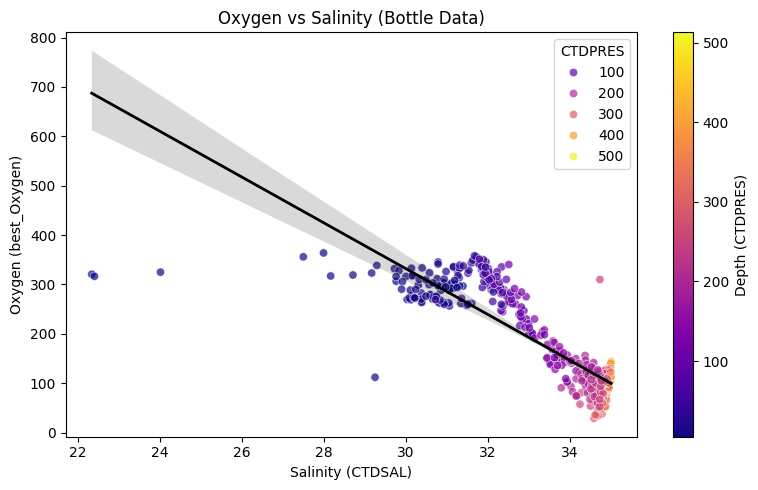

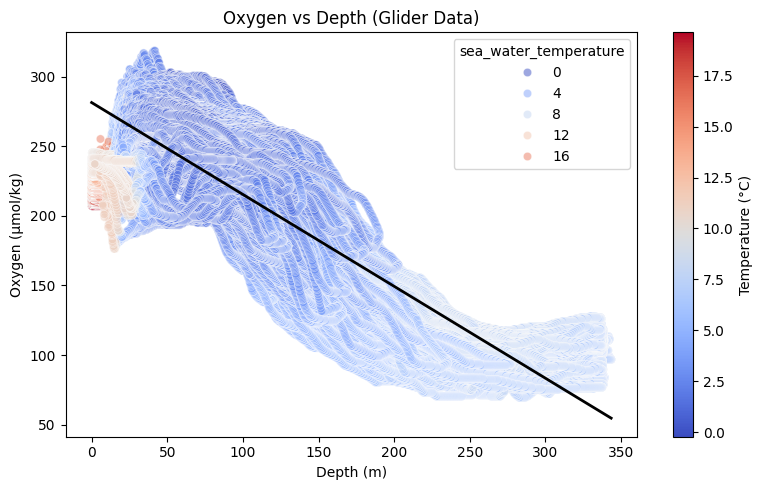

C:\Users\7PSYCHOPATH\AppData\Local\Temp\ipykernel_28012\723644471.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\7PSYCHOPATH\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


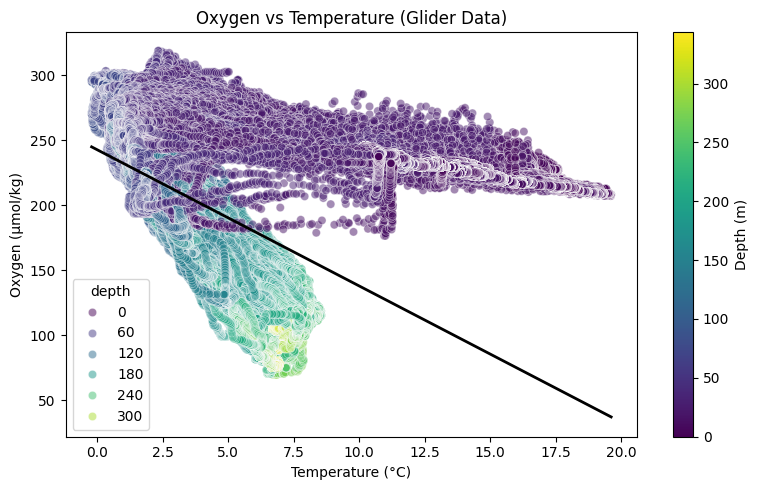

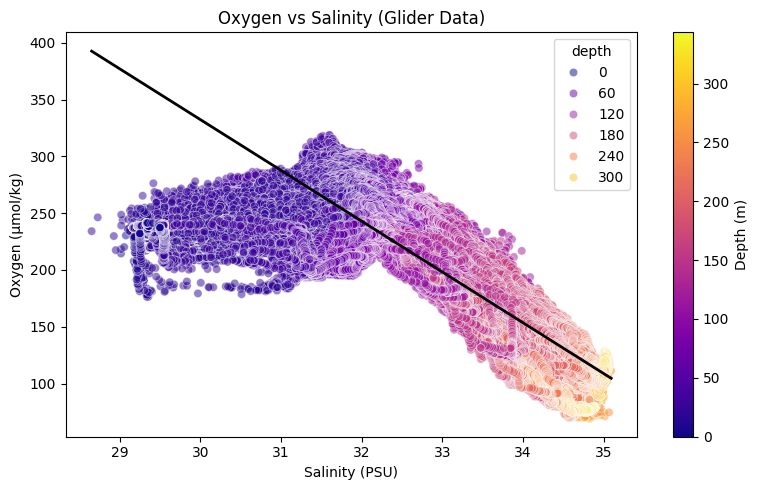

In [8]:
# Bottle Data
# Oxygen vs Depth (hue = Temperature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDPRES", y="best_Oxygen", hue="CTDTEMP", palette="coolwarm", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDPRES", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Depth (Bottle Data)")
ax.set_xlabel("Depth (CTDPRES)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDTEMP"].min(), df1["CTDTEMP"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Temperature (CTDTEMP)")
plt.tight_layout()
plt.show()

# Oxygen vs Temperature (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDTEMP", y="best_Oxygen", hue="CTDPRES", palette="viridis", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDTEMP", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Temperature (Bottle Data)")
ax.set_xlabel("Temperature (CTDTEMP)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDPRES"].min(), df1["CTDPRES"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (CTDPRES)")
plt.tight_layout()
plt.show()

# Oxygen vs Salinity (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDSAL", y="best_Oxygen", hue="CTDPRES", palette="plasma", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDSAL", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Salinity (Bottle Data)")
ax.set_xlabel("Salinity (CTDSAL)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDPRES"].min(), df1["CTDPRES"].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (CTDPRES)")
plt.tight_layout()
plt.show()


# Glider Data
# Oxygen vs Depth (hue = Temperature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="depth", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="sea_water_temperature", palette="coolwarm", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="depth", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Depth (Glider Data)")
ax.set_xlabel("Depth (m)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["sea_water_temperature"].min(), df2["sea_water_temperature"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Temperature (°C)")
plt.tight_layout()
plt.show()

# Oxygen vs Temperature (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="sea_water_temperature", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="depth", palette="viridis", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="sea_water_temperature", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Temperature (Glider Data)")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["depth"].min(), df2["depth"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (m)")
plt.tight_layout()
plt.show()

# Oxygen vs Salinity (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="sea_water_practical_salinity", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="depth", palette="plasma", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="sea_water_practical_salinity", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Salinity (Glider Data)")
ax.set_xlabel("Salinity (PSU)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["depth"].min(), df2["depth"].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (m)")
plt.tight_layout()
plt.show()


Findings:
- **Oxygen and Depth:** All six graphs show that oxygen levels decrease as depth increases. This matches with the expectation that oxygen levels drop with depth due to reduced light penetration and lower photosynthesis.  
- **Oxygen and Temprature:** The graphs show that cooler water tends to have higher  oxygen levels. This matches the known chemistry, cold water can dissolve more 
oxygen than warm water.
- **Oxygen and Salinity:** The graphs show that lower salinity water tends to have higher oxygen levels, while higher salinity water has lower oxygen levels. This matches with the expectation that salinity affects water density and oxygen availability, as saltier water is often denser and found at greater depths with less oxygen.  
- **Bottle vs Glider Data:** Both the bottle and glider data show similar trends in the relationships between oxygen levels, depth, temperature, and salinity. This consistency across different data collection methods suggests that these patterns are reliable and reflect real ocean conditions.

## Depth: Oceanography Visualization

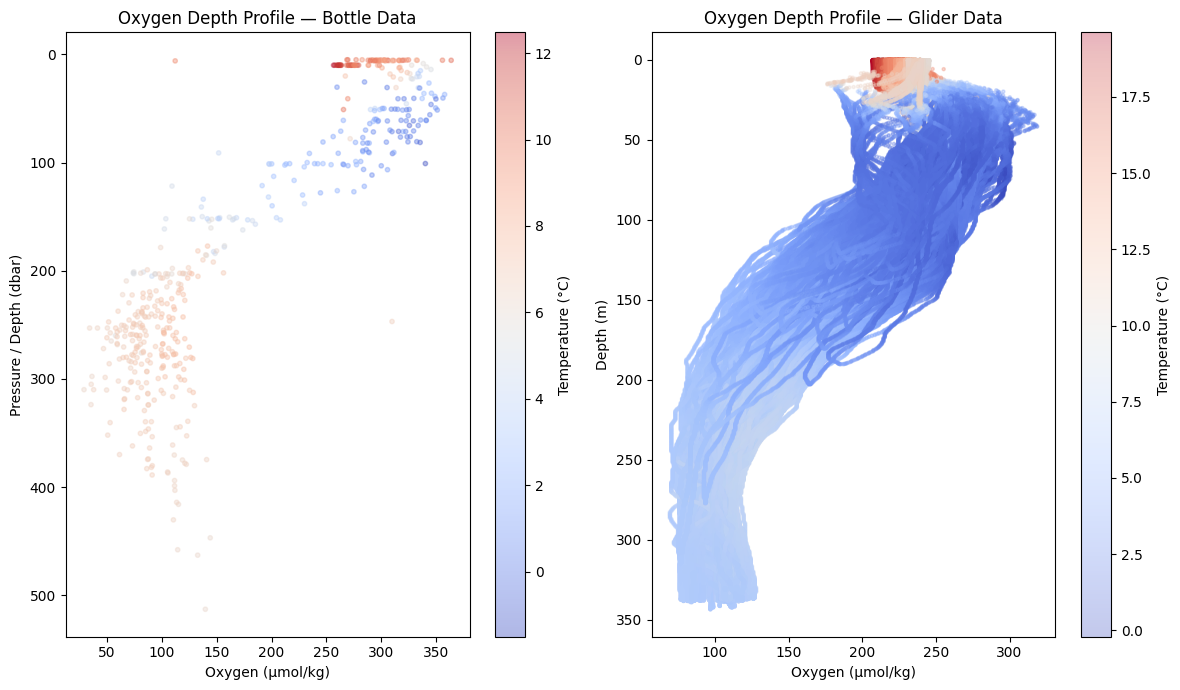

In [ ]:

# y-axis is inverted so depth increases downward, matching real ocean orientation
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Bottle data profile
sc1 = axes[0].scatter(df1["best_Oxygen"], df1["CTDPRES"],
                      alpha=0.4, c=df1["CTDTEMP"], cmap="coolwarm", s=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("Oxygen (µmol/kg)")
axes[0].set_ylabel("Pressure / Depth (dbar)")
axes[0].set_title("Oxygen Depth Profile — Bottle Data")
plt.colorbar(sc1, ax=axes[0], label="Temperature (°C)")

# Glider data profile
sc2 = axes[1].scatter(df2["micromoles_of_oxygen_per_unit_mass_in_sea_water"], df2["depth"],
                      alpha=0.3, c=df2["sea_water_temperature"], cmap="coolwarm", s=5)
axes[1].invert_yaxis()
axes[1].set_xlabel("Oxygen (µmol/kg)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Oxygen Depth Profile — Glider Data")
plt.colorbar(sc2, ax=axes[1], label="Temperature (°C)")

plt.tight_layout()
plt.show()

Findings:
- Both profiles confirm that oxygen decreases as depth increases, consistent with the scatter plots above.
- The inverted y-axis follows standard oceanographic convention. Depth increases downward to reflect real ocean orientation.
- Bottle data (left): The warm red dots cluster near the surface with high oxygen, while cold blue dots sink to depth with progressively lower oxygen. The mid-depths 
(200–400 dbar) show an oxygen minimum zone. A real oceanographic feature caused by reduced light penetration, lower photosynthesis, and biological oxygen consumption.
- Glider data (right): The swooping curves are the glider's actual dive paths through the water column as it repeatedly descended and ascended. The shape reveals a sharp oxygen drop below 50m, with consistently low values in the cold deep water below 100m.
- The color gradient in both plots confirms the temperature oxygen relationship, warmer surface water (red) holds more oxygen, colder deep water (blue) holds less.

In [10]:
# correlations
correlation = merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]].corr()
print("Correlation:\n", correlation)
# summary statistics
print("Summary Statistics:\n", merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]].describe())

Correlation:
                                                  best_Oxygen  \
best_Oxygen                                         1.000000   
micromoles_of_oxygen_per_unit_mass_in_sea_water     0.025101   
CTDTEMP                                            -0.376111   
CTDSAL                                             -0.898999   

                                                 micromoles_of_oxygen_per_unit_mass_in_sea_water  \
best_Oxygen                                                                             0.025101   
micromoles_of_oxygen_per_unit_mass_in_sea_water                                         1.000000   
CTDTEMP                                                                                -0.036559   
CTDSAL                                                                                  0.011286   

                                                  CTDTEMP    CTDSAL  
best_Oxygen                                     -0.376111 -0.898999  
micromoles_of_oxygen_per

The correlation matrix shows the strength and direction of relationships between variables:

- Oxygen (best_Oxygen) & Temperature (CTDTEMP): Correlation of -0.376, a moderate negative relationship. As temperature increases, oxygen concentration tends to decrease.

- Oxygen (best_Oxygen) & Salinity (CTDSAL): Correlation of -0.899, a strong negative relationship. As salinity increases, oxygen drops significantly. In the Gulf of St.Lawrence, salinity acts as a water mass fingerprint. Fresher surface layers hold more oxygen than the denser, saltier water below.

- Oxygen (best_Oxygen) & Micromoles of Oxygen per Unit Mass: Correlation of only 0.025. This near-zero value is explained by the merge quality. The glider dataset had limited time overlap with the bottle dataset, so the same 27 glider readings were repeated across all 481 bottle rows. The two columns are not measuring the same water.

- Temperature (CTDTEMP) & Salinity (CTDSAL): Correlation of 0.075, very weak. Temperature and salinity vary somewhat independently in this dataset.

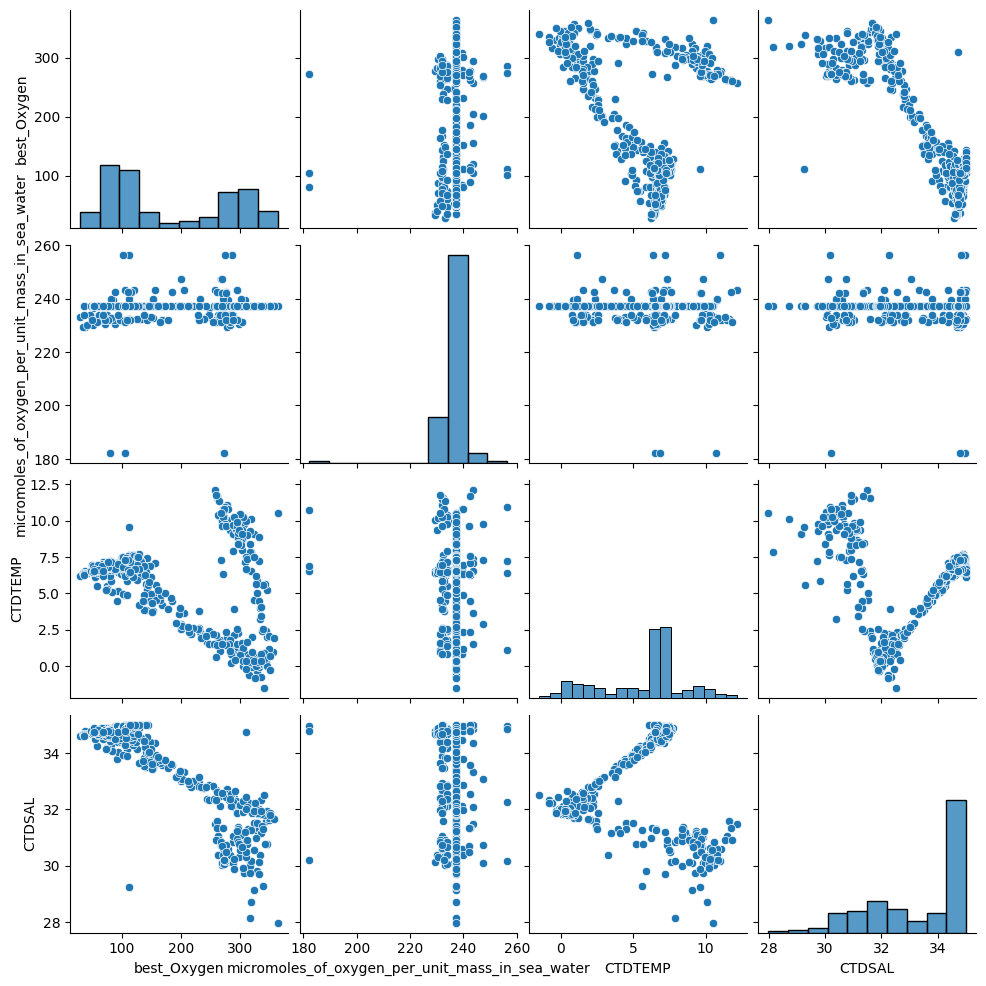

In [11]:
# pairplots
sns.pairplot(merged_df, vars=["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"])
plt.show()

The scatter plots shows how the variables relate to each other.

- **best_Oxygen vs. CTDTEMP:** There's a downward trend, which matches the negative correlation seen earlier.
- **best_Oxygen vs. CTDSAL:** A clear downward trend, which fits with the strong negative correlation we found.
- **CTDTEMP vs. CTDSAL:** There's no obvious pattern, which matches the very weak correlation between them.
- **Micromoles of Oxygen per Unit Mass:** This shows little to no connection with the other variables, just like the near-zero correlations.

## Time Series Analysis

In [12]:
print("First few rows of time series data:\n", merged_df[["time", "best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water"]].head())
print("\nDescriptive Statistics:\n", merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water"]].describe())

First few rows of time series data:
                  time  best_Oxygen  \
0 2021-10-22 21:07:00    28.908497   
1 2021-10-22 21:07:00    57.633972   
2 2021-10-22 21:07:00    90.840147   
3 2021-10-22 21:07:00   244.645609   
4 2021-10-22 21:07:00   265.664677   

   micromoles_of_oxygen_per_unit_mass_in_sea_water  
0                                       232.981556  
1                                       232.981556  
2                                       232.981556  
3                                       232.981556  
4                                       232.981556  

Descriptive Statistics:
        best_Oxygen  micromoles_of_oxygen_per_unit_mass_in_sea_water
count   481.000000                                       481.000000
mean    178.553107                                       236.533955
std     102.353648                                         5.263891
min      28.908497                                       182.273593
25%      87.624932                                

- best_Oxygen ranges from 28.91 to 363.90 with a standard deviation of 102.35, reflecting real variation across depths and water masses in the bottle dataset.

- The sensor oxygen (micromoles_of_oxygen_per_unit_mass_in_sea_water) shows very little variation (std = 5.26, range 182–256). This is not a calibration issue. It is a result of the time based merge. Only 27 unique glider readings existed, and these were repeated across all 481 bottle rows. 
- The bottle oxygen (best_Oxygen) is therefore the reliable variable and is used as the model target.

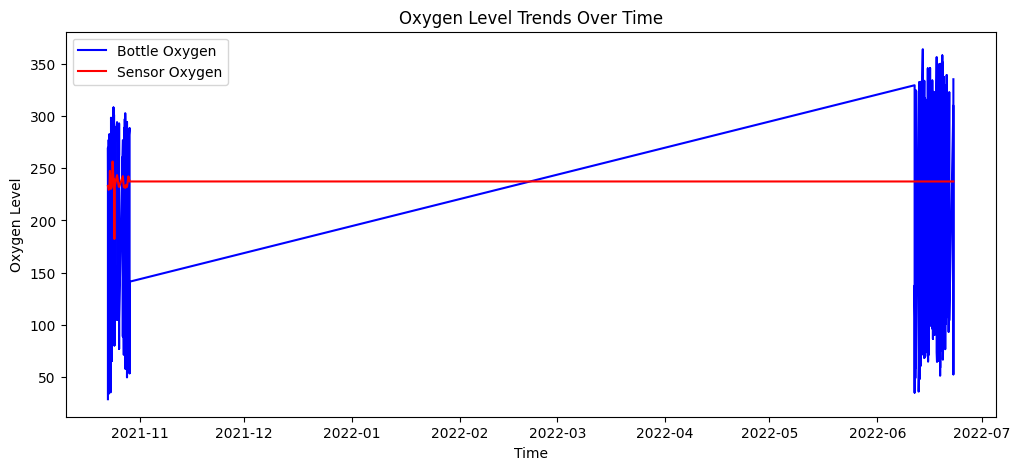

In [13]:
# Time series of oxygen levels
plt.figure(figsize=(12, 5))
plt.plot(merged_df["time"], merged_df["best_Oxygen"], label="Bottle Oxygen", color="blue")
plt.plot(merged_df["time"], merged_df["micromoles_of_oxygen_per_unit_mass_in_sea_water"], label="Sensor Oxygen", color="red")
plt.xlabel("Time")
plt.ylabel("Oxygen Level")
plt.title("Oxygen Level Trends Over Time")
plt.legend()
plt.show()

- The blue line, which represents best_Oxygen, shows a lot of ups and downs over time, indicating it changes quite a bit.

- The red line, representing micromoles_of_oxygen_per_unit_mass_in_sea_water, stays mostly steady, suggesting it doesn’t change much over the period observed.

- There is a sharp increase in best_Oxygen from around 2021-11 to 2022-06.

The near constant sensor oxygen values are a result of the time based merge. The 
glider dataset had limited overlap with the bottle dataset, causing the same glider 
readings to be repeated across many bottle rows. The bottle oxygen (best_Oxygen) is 
therefore the more reliable variable for analysis.

# Spatial Oxygen Distribution

In [14]:
print("First few rows of spatial data:\n", merged_df[["Longitude", "Latitude", "best_Oxygen"]].head())
print("\nDescriptive Statistics:\n", merged_df[["best_Oxygen"]].describe())

First few rows of spatial data:
    Longitude   Latitude  best_Oxygen
0   -67.2775  49.101389    28.908497
1   -67.2775  49.101389    57.633972
2   -67.2775  49.101389    90.840147
3   -67.2775  49.101389   244.645609
4   -67.2775  49.101389   265.664677

Descriptive Statistics:
        best_Oxygen
count   481.000000
mean    178.553107
std     102.353648
min      28.908497
25%      87.624932
50%     125.448426
75%     289.252788
max     363.904648


- The oxygen concentration values range from 28.91 to 363.90 with a mean of 178.55.

- There's a lot of variation, shown by the standard deviation of 102.35.

- The median (50th percentile) value is 125.45, which is lower than the mean. This suggests the distribution is right-skewed, meaning a few high values are pulling the average up.

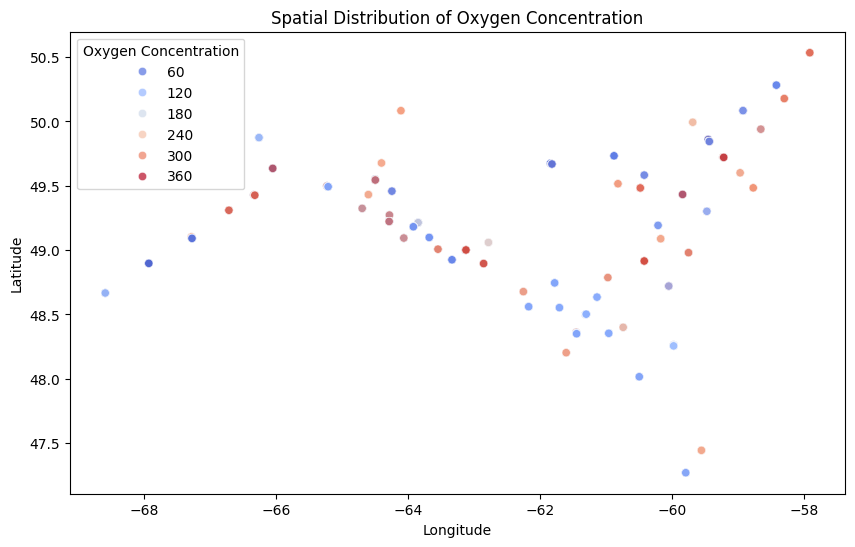

In [15]:
#scatter plot for spatial distribution of oxygen concentration
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x="Longitude", y="Latitude", hue="best_Oxygen", palette="coolwarm", alpha=0.7)
plt.legend(title="Oxygen Concentration")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Oxygen Concentration")
plt.show()

## Geographic Oxygen Map
The scatter plot above shows spatial distribution using axes. The interactive map below plots the same data on an actual geographic map, making regional patterns much clearer.

In [32]:
# Interactive geographic map of oxygen concentration
# Install if needed: pip install folium
import folium
from folium.plugins import HeatMap

center_lat = merged_df["Latitude"].mean()
center_lon = merged_df["Longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="CartoDB positron")

# Normalize oxygen values for color mapping (blue=low, red=high)
oxy_min = merged_df["best_Oxygen"].min()
oxy_max = merged_df["best_Oxygen"].max()

for _, row in merged_df.iterrows():
    norm = (row["best_Oxygen"] - oxy_min) / (oxy_max - oxy_min)
    r = int(255 * norm)
    b = int(255 * (1 - norm))
    color = f"#{r:02x}00{b:02x}"
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"O2: {row['best_Oxygen']:.1f} µmol/kg | Temp: {row['CTDTEMP']:.1f}°C | Sal: {row['CTDSAL']:.2f} PSU"
    ).add_to(m)

# Add heatmap layer
heat_data = [[row["Latitude"], row["Longitude"], row["best_Oxygen"]]
             for _, row in merged_df.iterrows()]
HeatMap(heat_data, name="Oxygen Heatmap", radius=15, blur=10).add_to(m)

folium.LayerControl().add_to(m)
m

Findings:
- The measurements correctly trace the Gulf of St. Lawrence and Cabot Strait exactly the geographic region this dataset covers.
- Blue markers indicate low oxygen concentration, red/yellow markers indicate high oxygen. The color variation across short geographic distances reflects the strong 
influence of local water mass structure rather than large scale geographic patterns.
- Clicking any marker shows the exact oxygen, temperature, and salinity reading at that location, allowing interactive exploration of the data.
- The heatmap layer highlights measurement density stations are concentrated along survey transects running east-west through the Gulf.
- Spatial clustering is visible: higher oxygen readings tend to appear in shallower nearshore areas, while lower oxygen concentrations appear in the deeper central Gulf consistent with the depth-salinity-oxygen relationship found throughout this analysis.

                                                 best_Oxygen  \
best_Oxygen                                         1.000000   
micromoles_of_oxygen_per_unit_mass_in_sea_water     0.025101   
CTDTEMP                                            -0.376111   
CTDSAL                                             -0.898999   

                                                 micromoles_of_oxygen_per_unit_mass_in_sea_water  \
best_Oxygen                                                                             0.025101   
micromoles_of_oxygen_per_unit_mass_in_sea_water                                         1.000000   
CTDTEMP                                                                                -0.036559   
CTDSAL                                                                                  0.011286   

                                                  CTDTEMP    CTDSAL  
best_Oxygen                                     -0.376111 -0.898999  
micromoles_of_oxygen_per_unit_mass_in_

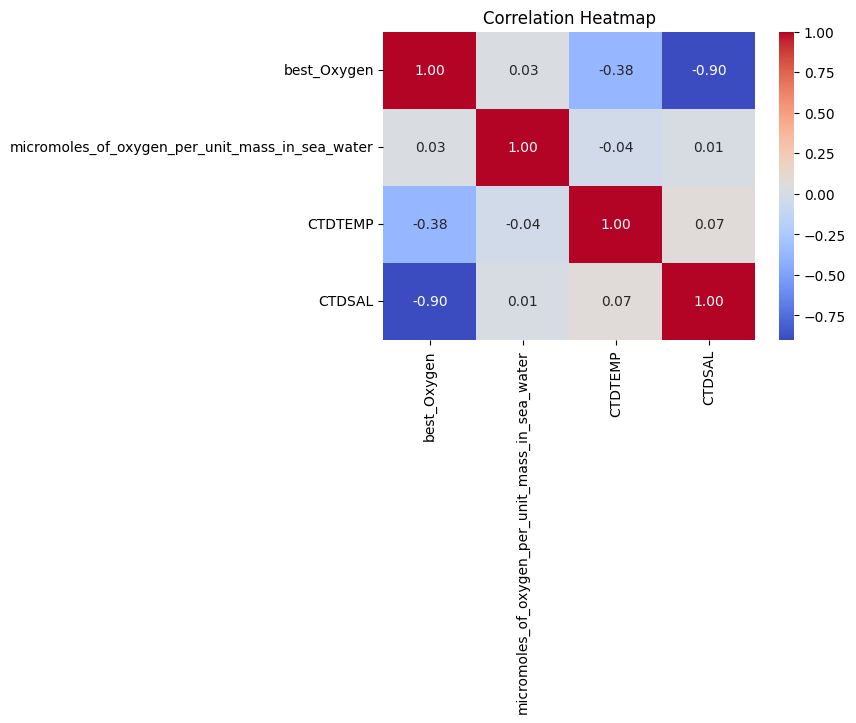

In [17]:
# Correaltion matrix
print(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


- best_Oxygen has a strong negative correlation with CTDSAL (-0.90), meaning that as salinity goes up, oxygen concentration drops a lot.

- best_Oxygen also shows a moderate negative correlation with temperature (CTDTEMP) of -0.38, showing that cooler temperatures are linked to higher oxygen levels.

- The near zero correlation (0.025) between best_Oxygen and the sensor oxygen is explained by the merge. only 27 unique glider readings were matched across 481  bottle rows. They are not comparable measurements.

---

## Train, Test Split

In [18]:
# Fixed setup — use only bottle dataset columns (df1), which have real variance
# The glider merge produced only 27 unique depth/oxygen values — not usable as a target

features = ["CTDTEMP", "CTDSAL", "CTDPRES"]  # all from df1, real variance
target = "best_Oxygen"                         # from df1, 481 unique values

# Fill any remaining missing values
merged_df[features] = merged_df[features].fillna(merged_df[features].mean())
merged_df[target] = merged_df[target].fillna(merged_df[target].mean())

X = merged_df[features]
y = merged_df[target]

X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"\nTarget — unique values: {y.nunique()}, std: {y.std():.4f}")
print(f"\nFeature variance check:")
for f in features:
    print(f"  {f}: {merged_df[f].nunique()} unique values, std={merged_df[f].std():.4f}")

Training set: (384, 3), Test set: (97, 3)

Target — unique values: 481, std: 102.3536

Feature variance check:
  CTDTEMP: 458 unique values, std=2.8539
  CTDSAL: 476 unique values, std=1.6860
  CTDPRES: 421 unique values, std=118.9333


## Random Forest Regression

In [19]:
#training Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest R² Score: {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")


Random Forest R² Score: 0.9161
Mean Absolute Error (MAE): 12.51


Results:
- R² Score: 0.916 — the model explains 92% of variance in oxygen concentration. It's a strong fit.
- MAE: 12.51 µmol/kg — on a target range of 29 to 364 µmol/kg, this represents an average error of about 3.7%, which is a good result.

In [20]:
#comparing model with Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)
print(f"Linear Regression R² Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

Linear Regression R² Score: 0.8573
Linear Regression MAE: 27.10


Results:
- R² Score: 0.857. Linear Regression now performs reasonably well, explaining 86% of variance. This makes sense because salinity has a near linear relationship with oxygen (-0.899 correlation), so a linear model can capture most of the pattern
- MAE: 27.10. Higher than Random Forest (12.51), confirming RF still models the non linear interactions better
- Random Forest outperforms Linear Regression, but the gap is smaller than expected. This is consistent with salinity dominating as a near linear predictor

In [21]:
# cross validation
# rf_model was already fitted on X_train, so we create a new one
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_cv, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Score: {np.mean(cv_scores):.4f}")
print(f"Std Dev: {np.std(cv_scores):.4f}") 

Cross-validation scores: [0.96650718 0.94930354 0.98008358 0.96530576 0.93400654]
Mean CV Score: 0.9590
Std Dev: 0.0159


Results:
- Cross-Validation Score (Mean): All 5 folds score between 0.93–0.98, which means the model generalises consistently to unseen data
- The low standard deviation shows stability across different  data subsets. No sign of overfitting

In [22]:
#hyperparameter tuning
#defining the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

#setting up GridSearchCV and fitting the model
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)


print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.9738884497033405


Results:
- Best parameters: n_estimators=200, max_depth=None, min_samples_leaf=4, min_samples_split=2
- Best CV score: 0.974 — confirms the tuned model generalises well across all folds.
- min_samples_leaf=4 means each leaf node must contain at least 4 samples, preventing the model from fitting to individual noisy data points.

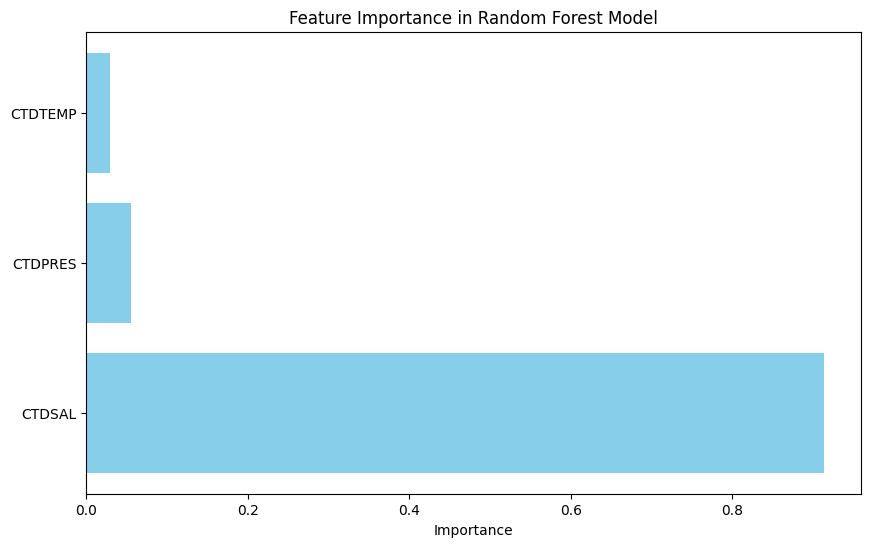

   Feature  Importance
1   CTDSAL    0.914351
2  CTDPRES    0.055871
0  CTDTEMP    0.029779


In [23]:
#fitting rf model and getting feature imprtances
rf_model.fit(X_train, y_train)
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.show()


print(feature_importance_df)

- Salinity is by far the dominant predictor (91.4%), followed by pressure (5.6%) 
and temperature (3.0%)
- This aligns with the strong negative correlation seen in the EDA (-0.899)
- In the Gulf of St. Lawrence, salinity stratification is a primary driver 
of oxygen availability. Fresher surface water holds more dissolved oxygen than the 
denser saline water below.

---

## Feature Ablation: Effect of Removing Salinity
Since salinity dominates feature importance at 91.4%, we test what happens when it is removed. This checks whether the model relies on salinity uniquely, or whether other correlated features (like pressure) can compensate.

--- Feature Ablation: Removing Salinity ---
R² WITH salinity (full model):     0.9161
R² WITHOUT salinity (temp + pres): 0.8974
R² drop from removing salinity:    0.0188
Salinity alone accounts for ~2.0% of the model's explanatory power.


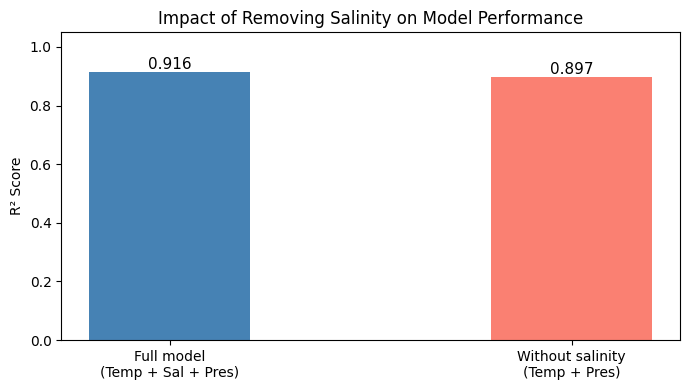

In [26]:
# Feature ablation: train without salinity to measure its true contribution
features_no_sal = ["CTDTEMP", "CTDPRES"]
X_no_sal = StandardScaler().fit_transform(merged_df[features_no_sal])
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sal, y, test_size=0.2, random_state=42
)

rf_no_sal = RandomForestRegressor(n_estimators=100, random_state=42)
rf_no_sal.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_no_sal.predict(X_test_ns)
r2_no_sal = r2_score(y_test_ns, y_pred_ns)

print("--- Feature Ablation: Removing Salinity ---")
print(f"R² WITH salinity (full model):     {r2_rf:.4f}")
print(f"R² WITHOUT salinity (temp + pres): {r2_no_sal:.4f}")
print(f"R² drop from removing salinity:    {r2_rf - r2_no_sal:.4f}")
print(f"Salinity alone accounts for ~{(r2_rf - r2_no_sal) / r2_rf * 100:.1f}% of the model's explanatory power.")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
models = ["Full model\n(Temp + Sal + Pres)", 
          "Without salinity\n(Temp + Pres)"]
scores = [r2_rf, r2_no_sal]
colors = ["steelblue", "salmon"]
bars = ax.bar(models, scores, color=colors, width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel("R² Score")
ax.set_title("Impact of Removing Salinity on Model Performance")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

In [31]:
print("Correlation between features:")
print(merged_df[["CTDTEMP", "CTDSAL", "CTDPRES"]].corr())
print()
print("Salinity vs Pressure correlation:", 
      merged_df["CTDSAL"].corr(merged_df["CTDPRES"]))

Correlation between features:
          CTDTEMP    CTDSAL   CTDPRES
CTDTEMP  1.000000  0.074990  0.202483
CTDSAL   0.074990  1.000000  0.926967
CTDPRES  0.202483  0.926967  1.000000

Salinity vs Pressure correlation: 0.9269673336344824


Findings:
- Removing salinity causes only a small drop in R² (0.916 to 0.897, a drop of 0.019), despite salinity having 91.4% feature importance in the full model.
- The correlation between salinity and pressure in this dataset is 0.927; near perfect, confirming they carry almost identical information about water mass structure.
- This contradiction is explained by multicollinearity Salinity and pressure are correlated in this dataset, since deeper water in the Gulf of St.Lawrence tends to be saltier. When salinity is removed, pressure absorbs much 
of its predictive role.
- This means the model is capturing a combined depth salinity signal that reflects water mass structure, rather than salinity alone being a standalone driver.
- Feature importance in Random Forest can overstate one variable's contribution when predictors are correlated this ablation test reveals the true picture.
- Conclusion: both salinity and pressure together define the water mass identity, which is the real driver of oxygen concentration in this region.

In [28]:
#fitting best rf model
best_rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=None, 
    min_samples_leaf=4, 
    min_samples_split=2, 
    random_state=42
)
best_rf_model.fit(X_train, y_train)

y_pred_best = best_rf_model.predict(X_test)
print(f"Best Model R² Score: {r2_score(y_test, y_pred_best):.4f}")
print(f"Best Model MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")


Best Model R² Score: 0.9138
Best Model MAE: 13.0338


Results:

- R² Score: 0.914. The tuned model explains 91.4% of variance, nearly identical to the Random Forest (0.916). 
- MAE: 13.03. On a target range of 29 to 364, this is an average  error of 3.9%. The slight increase from the baseline (12.51) reflects the same  generalization tradeoff.
- The CV score of 0.959 being higher than the test R² of 0.914 is normal. CV averages across all data folds while the test set is a fixed 20% slice.

---

## Model Evaluation: Actual vs Predicted
- Comparing the actual vs predicted values and assess the performance of tuned Random Forest model

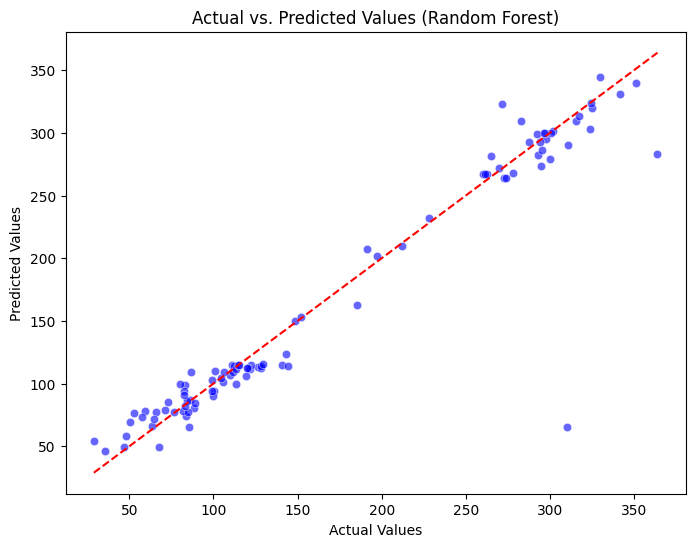

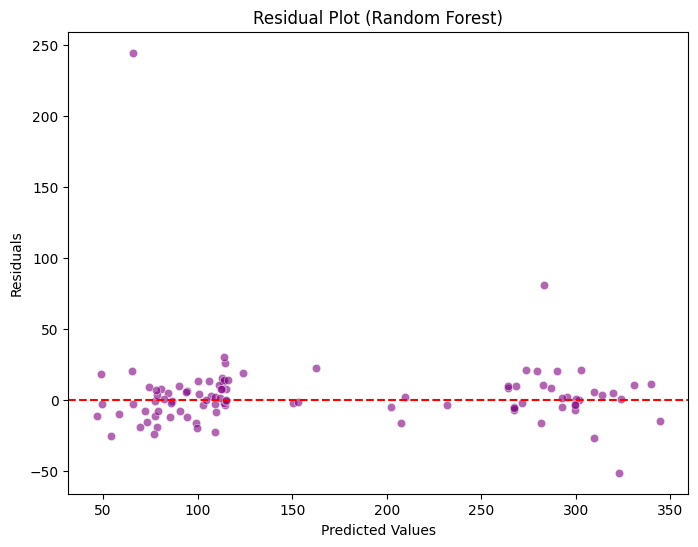

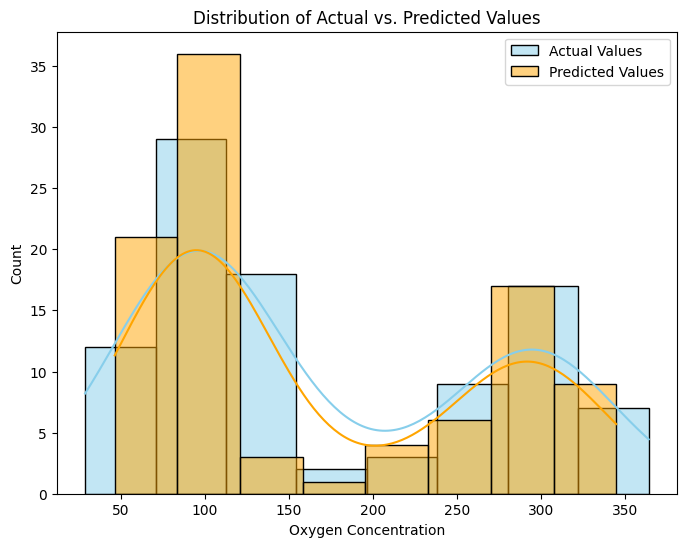

In [29]:
#scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs. Predicted Values (Random Forest)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

#residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_best, y=residuals, color='purple', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Random Forest)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#distribution plot
plt.figure(figsize=(8, 6))
sns.histplot(y_test, label='Actual Values', color='skyblue', kde=True)
sns.histplot(y_pred_best, label='Predicted Values', color='orange', kde=True)
plt.title('Distribution of Actual vs. Predicted Values')
plt.xlabel('Oxygen Concentration')
plt.legend()
plt.show()


Results:
- Actual vs. Predicted: Most points cluster tightly along the diagonal, confirming strong predictive performance. Slight scatter at the extremes (very low and very 
  high oxygen values) shows the model is less confident at the boundaries of the range
- Residual plot: Residuals are centered around zero with no clear pattern, indicating the model is not systematically over or under predicting
- Distribution plot: Predicted and actual distributions closely overlap, though the model slightly smooths extreme values. A common behavior in Random Forest due to averaging across trees